In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
precision_score, recall_score, f1_score, roc_auc_score,
confusion_matrix, classification_report,
roc_curve, precision_recall_curve
)


import matplotlib.pyplot as plt
import xgboost as xgb
import joblib


RANDOM_STATE = 42

In [2]:
#dataset import
df = pd.read_parquet("C:/Users/elhay/Downloads/ieee_fraud_detection.parquet")

In [3]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (590528, 202)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Feature Selection
TARGET = 'isFraud'
# Prioritized features based on domain knowledge
PRIORITY_FEATURES = [
'card4', 'card6', 'P_emaildomain',
'TransactionAmt', 'C13', 'C1', 'C14'
]

# Check for missing prioritized features
missing_features = [f for f in PRIORITY_FEATURES + [TARGET] if f not in df.columns]

# Raise error if any required features are missing
if missing_features:
    raise ValueError(f"Missing required features: {missing_features}")


print('All prioritized features are present.')

All prioritized features are present.


In [5]:
# Split the data
X = df[PRIORITY_FEATURES] #features
y = df[TARGET] #target

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Display the shapes of the splits
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (472422, 7)
Test shape: (118106, 7)


In [6]:
# Define feature types
numeric_features = ['TransactionAmt', 'C13', 'C1', 'C14']
categorical_features = ['card4','card6', 'P_emaildomain']

In [7]:
# Numeric: median imputation handled by XGBoost
X_train[categorical_features] = X_train[categorical_features].fillna('missing')
X_test[categorical_features] = X_test[categorical_features].fillna('missing')

In [8]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
('scaler', StandardScaler())
])


categorical_transformer = Pipeline(steps=[
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [9]:
# Calculate scale_pos_weight for XGBoost
fraud_ratio = y_train.value_counts()
scale_pos_weight = fraud_ratio[0] / fraud_ratio[1]
print('scale_pos_weight:', scale_pos_weight)

scale_pos_weight: 27.579673321234118


In [10]:
# Define XGBoost model with tuned hyperparameters
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE
)

In [11]:
# Create the full pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])


model_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# Train the model
model_pipeline.fit(X_train, y_train)
print('Model training completed.')

Model training completed.


In [13]:
# Make predictions
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

In [14]:
# Evaluate the model
precision = precision_score(y_test, y_pred) # Evaluate precision
recall = recall_score(y_test, y_pred) # Evaluate recall
f1 = f1_score(y_test, y_pred) # Evaluate F1-score
roc_auc = roc_auc_score(y_test, y_proba) # Evaluate ROC-AUC

# Print evaluation metrics
print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)
print('ROC-AUC:', roc_auc)

Precision: 0.16011693933771856
Recall: 0.6890878296636825
F1-score: 0.25985401459854013
ROC-AUC: 0.862498301110699


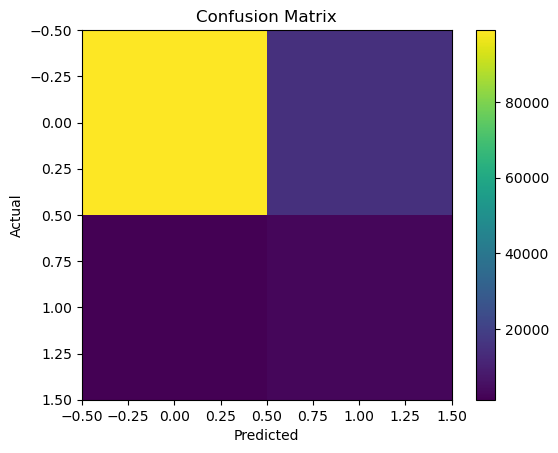

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)


plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

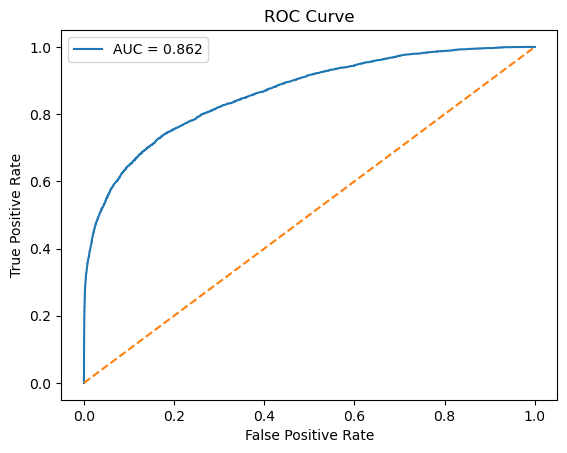

In [16]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)


plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

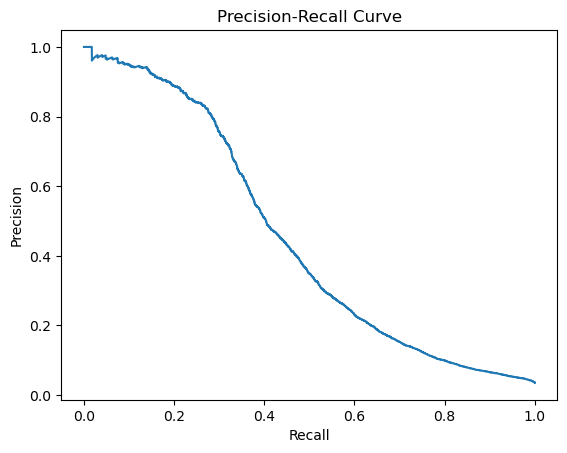

In [17]:
# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)


plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

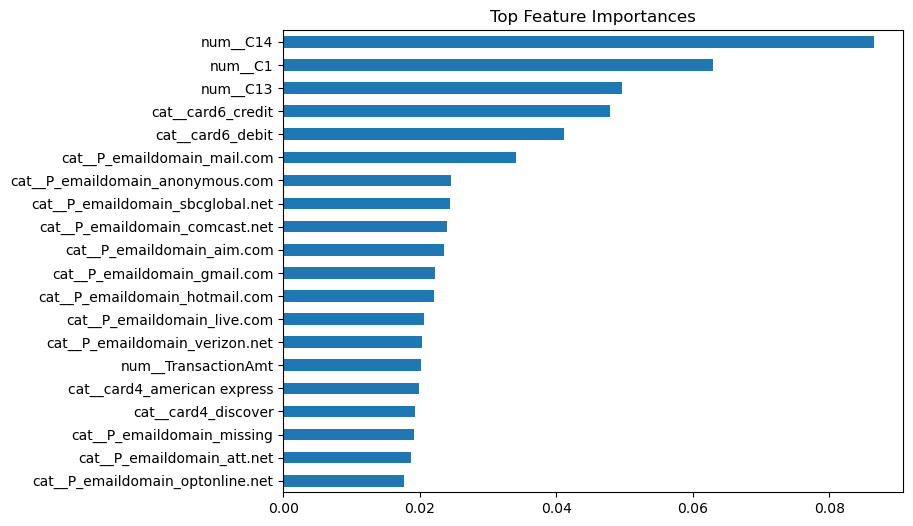

In [18]:
# Feature Importance
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = model_pipeline.named_steps['model'].feature_importances_

# Get top 20 important features
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]


plt.figure(figsize=(8,6))
fi.plot(kind='barh')
plt.title('Top Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [23]:
# Save the model
model_filename = 'Fraud_Detection_Pipeline.pkl'
joblib.dump(model_pipeline, model_filename)
print(f"Model saved to {model_filename}")



Model saved to Fraud_Detection_Pipeline.pkl
